In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data mining for cybersecurity - data/Live GPS Spoofing and Jamming/UAV_Attack_Dataset_SUBSET.csv')

In [3]:
selected_features = ['control[0]',
    'control[1]',
    'control[2]',
    'control[3]',
    'vel_m_s',
    'vel_n_m_s',
   'vel_e_m_s',
   'vel_d_m_s',
   'gps_hvel[0]_var',
  'gps_hvel[0]_inn',
  'gps_hvel[1]_inn',
  'gps_vvel_inn',
  'gps_hpos[0]_inn',
  'gps_hpos[1]_inn']
data_subset = data[selected_features]

In [4]:
X = data_subset
y = data['class']

In [5]:
class_mapping = {
    'benign flight': 0,
    'gps jamming': 1,
    'gps spoofing': 2
    }

In [6]:
y = y.map(class_mapping)

In [7]:
# FEATURE ENGINEERING

print("FEATURE ENGINEERING")

# Control Signal Statistics
control_columns = [c for c in X.columns if 'control' in c]
if len(control_columns) > 1:
    X['control_std'] = X[control_columns].std(axis=1)

# GPS Variance Sum
variance_columns = [c for c in X.columns if '_var' in c]
if len(variance_columns) > 1:
    X['gps_var_sum'] = X[variance_columns].sum(axis=1)

# GPS Innovation Sum
innovation_columns = [c for c in X.columns if '_inn' in c]
if len(innovation_columns) > 1:
    X['gps_inn_sum'] = X[innovation_columns].abs().sum(axis=1)
    print("Created: gps_inn_sum (Sum of Absolute Innovations)")

print(f"\n Total features after engineering: {X.shape[1]}")

FEATURE ENGINEERING
Created: gps_inn_sum (Sum of Absolute Innovations)

 Total features after engineering: 16


/tmp/ipykernel_356/2959810596.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['control_std'] = X[control_columns].std(axis=1)
/tmp/ipykernel_356/2959810596.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['gps_inn_sum'] = X[innovation_columns].abs().sum(axis=1)


In [8]:
from google.colab import files

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

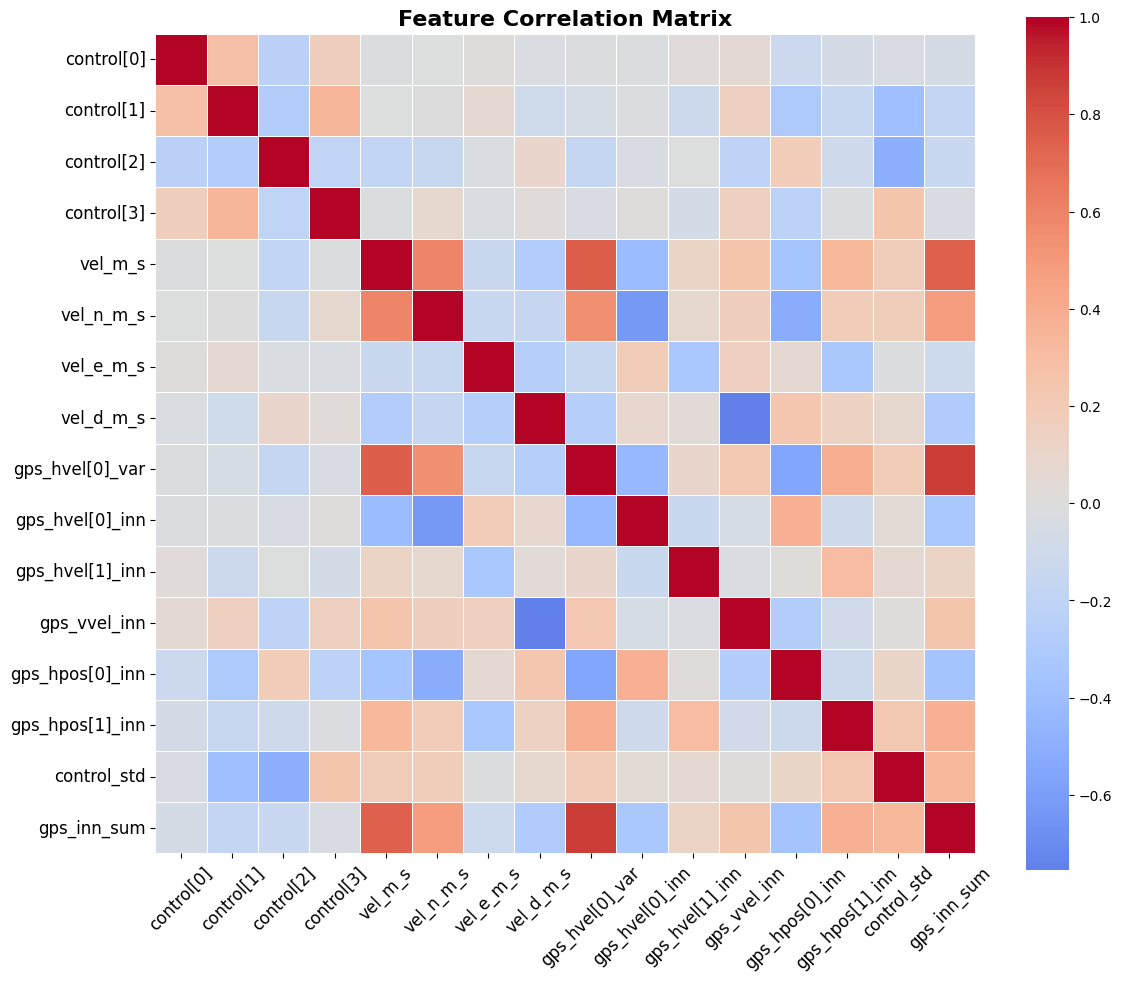

In [12]:
# CORRELATION MATRIX VISUALIZATION
plt.figure(figsize=(12, 10))

correlation = X.corr()

sns.heatmap(correlation, cmap='coolwarm', center=0, annot=False,
            square=True, linewidths=0.5,
            xticklabels=correlation.columns,
            yticklabels=correlation.columns,
           )
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=16)

plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()

plt.savefig('correlation_matrix.pdf', format='pdf', dpi=300, bbox_inches='tight')

files.download('correlation_matrix.pdf')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.90)),
    ("knn", KNeighborsClassifier(
        n_neighbors=35,
        weights="uniform",
        metric="manhattan"
    ))
])

In [ ]:
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print("Hold-out Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Hold-out Accuracy: 0.7421487603305785
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       493
           1       0.67      0.76      0.71       444
           2       0.77      0.54      0.63       273

    accuracy                           0.74      1210
   macro avg       0.75      0.71      0.72      1210
weighted avg       0.75      0.74      0.74      1210



In [ ]:
y_pred_train = pipe.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, y_pred_train))

Training Accuracy: 0.7473118279569892


In [ ]:
cv_scores = cross_val_score(
    pipe,
    X,
    y,
    cv=10,
    scoring="accuracy"
)

print("Fold skorları:", cv_scores)
print("Ortalama CV Accuracy:", cv_scores.mean())

Fold skorları: [0.73057851 0.74876033 0.74214876 0.74710744 0.74049587 0.74545455
 0.74668874 0.74668874 0.70198675 0.72682119]
Ortalama CV Accuracy: 0.7376730885009031


In [ ]:
param_grid = {
    "knn__n_neighbors": [3,5,7,9,11,13,15,21,35],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X, y)


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.9)),
                                       ('knn',
                                        KNeighborsClassifier(metric='manhattan',
                                                             n_neighbors=35))]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 21, 35],
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
print("The Best CV Score:", grid.best_score_)
print("The Best Parameters:", grid.best_params_)

The Best CV Score: 0.82087324174922
The Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}


In [ ]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Final Test Accuracy: 0.8190082644628099
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       493
           1       0.77      0.81      0.79       444
           2       0.79      0.74      0.77       273

    accuracy                           0.82      1210
   macro avg       0.81      0.81      0.81      1210
weighted avg       0.82      0.82      0.82      1210



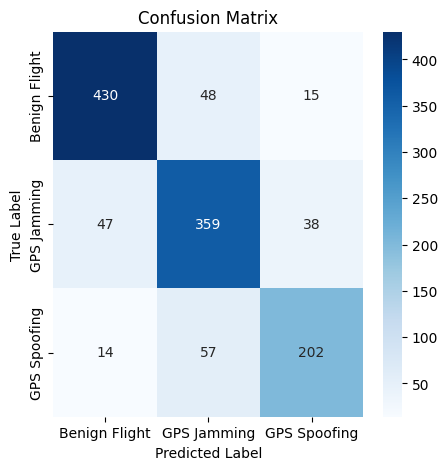

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap=plt.cm.Blues, xticklabels=['Benign Flight', 'GPS Jamming', 'GPS Spoofing'], yticklabels=['Benign Flight', 'GPS Jamming', 'GPS Spoofing'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
